In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:


data = {
    'Area': [800, 1000, 1200, 1500, 1800, 2000, 2200, 2500],
    'Bedrooms': [1, 2, 2, 3, 3, 4, 4, 5],
    'Age': [10, 8, 5, 4, 3, 2, 2, 1],
    'Location_Score': [5, 6, 7, 8, 8, 9, 9, 10],
    'Price': [25, 32, 45, 60, 70, 85, 95, 120]  # in Lakhs
}

df = pd.DataFrame(data)
print(df)



   Area  Bedrooms  Age  Location_Score  Price
0   800         1   10               5     25
1  1000         2    8               6     32
2  1200         2    5               7     45
3  1500         3    4               8     60
4  1800         3    3               8     70
5  2000         4    2               9     85
6  2200         4    2               9     95
7  2500         5    1              10    120


In [9]:
X = df[['Area', 'Bedrooms', 'Age', 'Location_Score']]
y = df['Price']
print(X)
print(y)

   Area  Bedrooms  Age  Location_Score
0   800         1   10               5
1  1000         2    8               6
2  1200         2    5               7
3  1500         3    4               8
4  1800         3    3               8
5  2000         4    2               9
6  2200         4    2               9
7  2500         5    1              10
0     25
1     32
2     45
3     60
4     70
5     85
6     95
7    120
Name: Price, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
model= LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
coefficients= pd.DataFrame({
 'Feature':X_train.columns,
 'Importance(Coefficient)':model.coef_

})
print(coefficients)

          Feature  Importance(Coefficient)
0            Area                    0.075
1        Bedrooms                  -37.500
2             Age                   15.000
3  Location_Score                   50.000


In [16]:
y_pred= model.predict(X_test)
print(
"Actual pricse:", y_test.values,
"\nPredicted prices:", y_pred
)

Actual pricse: [32 85] 
Predicted prices: [22.5 82.5]


In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)


MAE: 6.000000000000057
MSE: 48.25000000000068
RMSE: 6.946221994724952


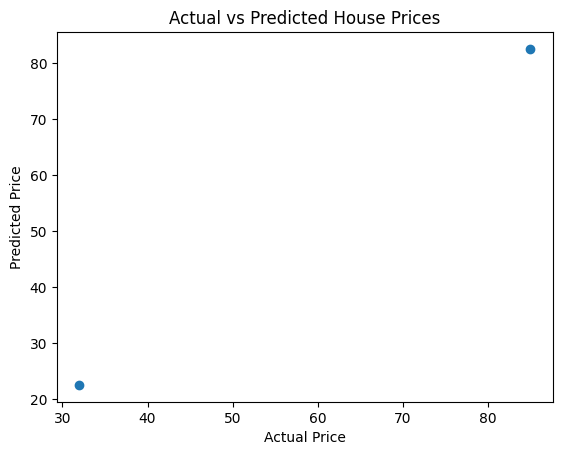

In [18]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()


In [19]:
new_house = np.array([[1600, 3, 4, 8]])  # Example features
predicted_price = model.predict(new_house)
print("Predicted price for the new house:", predicted_price[0], "Lakhs")

Predicted price for the new house: 70.00000000000006 Lakhs


C:\Users\Dell 5490T\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


for solving the mse,mae,rmse prediction using off ridge ,lasso ,standardscaler and elasticnet

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [45]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.0001)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)


this isfor over come the mistakes off mse,mae,rmse by the we improve thevalue 

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge MAE:", mae_ridge)
print("Ridge RMSE:", rmse_ridge)


Ridge MAE: 3.4249534269882744
Ridge RMSE: 4.1345787483242615


in this we show that by appling ridge we remove the overfitting problem  in this we have to change the value ofalpha by the process we gate the maximaum overfitting 

In [24]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))


Lasso MAE: 6.397694498502542
Lasso RMSE: 6.7021161023502165


by this we understand about there is no  useless fature in data so lasso fail 

In [25]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)

print("ElasticNet MAE:", mean_absolute_error(y_test, y_pred_elastic))
print("ElasticNet RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_elastic)))


ElasticNet MAE: 6.044111028782286
ElasticNet RMSE: 6.170061472299011
